In [1]:
import torch
import torch.nn as nn
import open_clip
import torchvision
import torchvision.transforms as transforms
import numpy as np
import collections
import os
import shutil
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from PIL import Image
import matplotlib.pyplot as plt

C:\Users\panag\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Φορτώνουμε το CLIP ως feature extractor
# Διαφορά από K-Means με ResNet/MobileNet:
# - ResNet/MobileNet: features από visual patterns (textures, edges, colors)
# - CLIP: features από semantic understanding ("τι αναπαριστά η εικόνα")
clip_model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai')
clip_model = clip_model.to(device)
clip_model.eval()
print('CLIP φορτώθηκε!')
print(f'Feature dimensions: 512 (CLIP ViT-B/32)')

C:\Users\panag\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP φορτώθηκε!
Feature dimensions: 512 (CLIP ViT-B/32)


In [3]:
# Dataset
# Χρησιμοποιούμε το preprocess του CLIP (όχι το συνηθισμένο ImageNet transform)
all_dataset = torchvision.datasets.ImageFolder(
    root="C:/Users/panag/Desktop/Thesis/Datasets/AllImages/All2",
    transform=preprocess)  # ← CLIP preprocess αντί για κανονικό transform

all_loader = torch.utils.data.DataLoader(
    all_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f'Συνολικές εικόνες: {len(all_dataset)}')

Συνολικές εικόνες: 2263


In [4]:
# ΒΗΜΑ 1: Εξαγωγή CLIP features
# Το CLIP παράγει 512-dim features (ViT-B/32)
# που περιέχουν semantic πληροφορία για κάθε εικόνα
all_features = []

with torch.no_grad():
    for i, (inputs, _) in enumerate(all_loader):
        inputs = inputs.to(device)
        # encode_image: εξάγει τα visual features από το CLIP
        features = clip_model.encode_image(inputs)
        # L2 normalize (το CLIP το κάνει συνήθως αυτόματα)
        features = features / features.norm(dim=-1, keepdim=True)
        all_features.extend(features.cpu().numpy())

        if (i+1) % 10 == 0:
            print(f'Processed: {(i+1)*32}/{len(all_dataset)}')

all_features = np.array(all_features)
print(f'\nFeatures shape: {all_features.shape}')  # (3059, 512)

Processed: 320/2263
Processed: 640/2263
Processed: 960/2263
Processed: 1280/2263
Processed: 1600/2263
Processed: 1920/2263
Processed: 2240/2263

Features shape: (2263, 512)


Components για 95% variance: 237


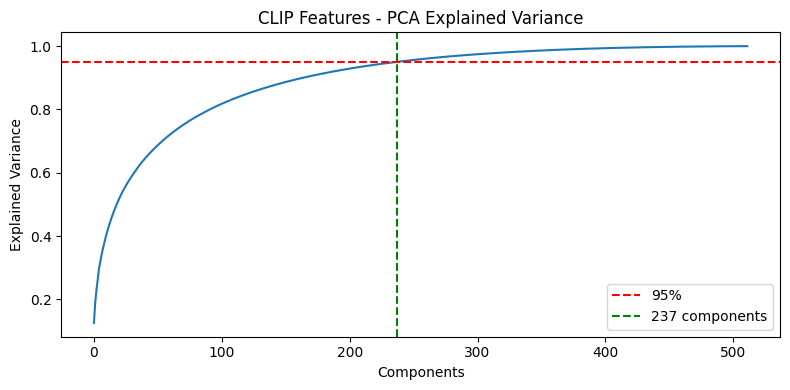

In [5]:
# ΒΗΜΑ 2: Preprocessing
# StandardScaler για ομοιόμορφη κλίμακα
scaler = StandardScaler()
features_scaled = scaler.fit_transform(all_features)

# L2 Normalization (ενισχύει τη γωνιακή ομοιότητα)
features_scaled = normalize(features_scaled, norm='l2')

# PCA - τα CLIP features είναι 512-dim
# Βρίσκουμε πόσα components χρειαζόμαστε για 95% variance
pca_full = PCA(random_state=42)
pca_full.fit(features_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumsum >= 0.95) + 1
print(f'Components για 95% variance: {n_components}')

# Plot explained variance
plt.figure(figsize=(8, 4))
plt.plot(cumsum)
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} components')
plt.xlabel('Components')
plt.ylabel('Explained Variance')
plt.title('CLIP Features - PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Εφαρμογή PCA με τον αριθμό που βρήκαμε
pca = PCA(n_components=n_components, random_state=42)
features_pca = pca.fit_transform(features_scaled)
print(f'Features μετά PCA: {features_pca.shape}')

Features μετά PCA: (2263, 237)


In [7]:
# ΒΗΜΑ 3: K-Means Clustering
# Ίδιες παράμετροι με τα προηγούμενα K-Means experiments
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50,
    max_iter=500
)
clusters = kmeans.fit_predict(features_pca)

print(f'Cluster distribution: {collections.Counter(clusters)}')
print(f'Inertia: {kmeans.inertia_:.2f}')

Cluster distribution: Counter({np.int32(0): 897, np.int32(2): 817, np.int32(1): 549})
Inertia: 1831.60


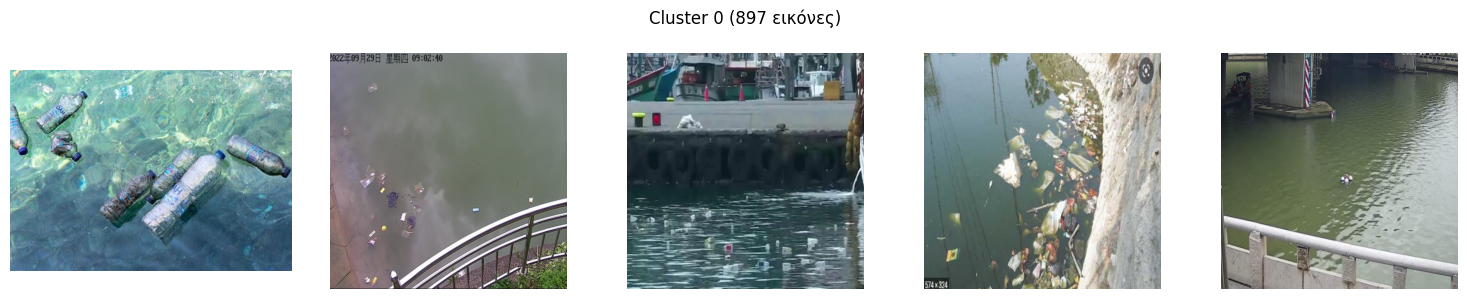

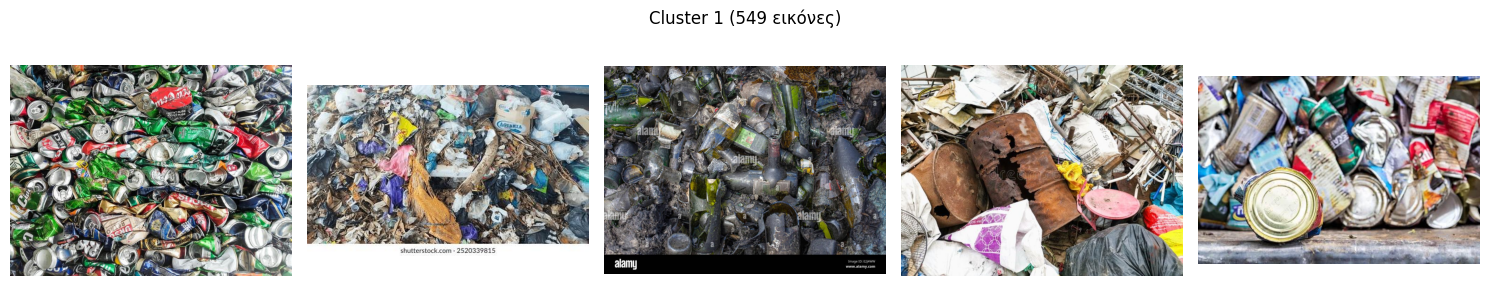

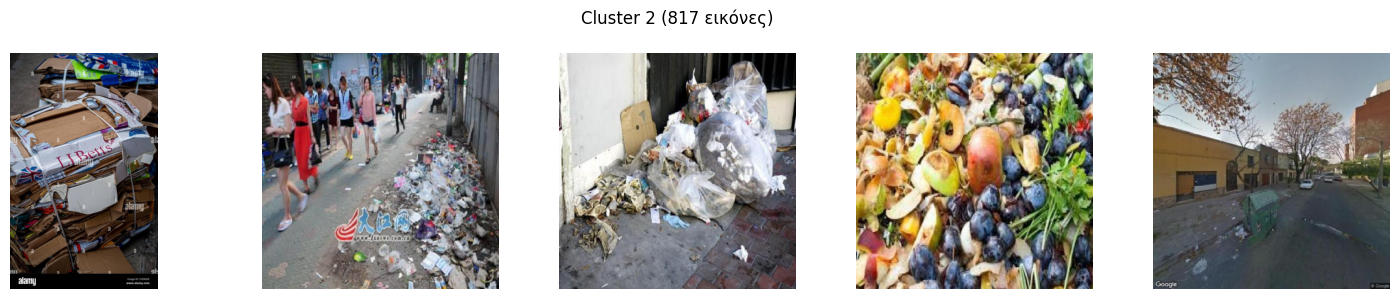

In [8]:
# ΒΗΜΑ 4: Οπτικός έλεγχος clusters
# ΣΗΜΑΝΤΙΚΟ: Ελέγξε τις εικόνες για να αντιστοιχίσεις σωστά!
image_paths = [all_dataset.imgs[i][0] for i in range(len(all_dataset))]

for cluster_id in [0, 1, 2]:
    idxs = [i for i, c in enumerate(clusters) if c == cluster_id][:5]
    count = len([c for c in clusters if c == cluster_id])
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f'Cluster {cluster_id} ({count} εικόνες)')
    for ax, idx in zip(axes, idxs):
        img = Image.open(image_paths[idx])
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [9]:
# ΒΗΜΑ 5: Αντιστοίχιση Clusters → Κατηγορίες
# Άλλαξε ΑΦΟΥ δεις τις εικόνες στο ΒΗΜΑ 4!
cluster_names = {
    0: "NoWaste",
    1: "Low",
    2: "High"
}

In [10]:
# ΒΗΜΑ 6: Αποθήκευση dataset
output_dir = "C:/Users/panag/Desktop/Thesis/Datasets/KMeans_Dataset_with_CLIP"

for name in cluster_names.values():
    os.makedirs(f"{output_dir}/train/{name}", exist_ok=True)
    os.makedirs(f"{output_dir}/test/{name}", exist_ok=True)

for i, (path, cluster) in enumerate(zip(image_paths, clusters)):
    category = cluster_names[cluster]
    split = "train" if i % 5 != 0 else "test"
    filename = os.path.basename(path)
    shutil.copy(path, f"{output_dir}/{split}/{category}/{filename}")

print('Completed!')
print(f'\nΚατανομή dataset:')
for cluster_id, name in cluster_names.items():
    count = list(clusters).count(cluster_id)
    print(f'  {name}: {count} εικόνες')

Completed!

Κατανομή dataset:
  NoWaste: 897 εικόνες
  Low: 549 εικόνες
  High: 817 εικόνες
